In [ ]:
import os
import random
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/Datasets/isic
!ls /content/drive/MyDrive/Datasets/pets
!ls /content/drive/MyDrive/Datasets/deepglobe

!cp -r /content/drive/MyDrive/Datasets/isic /content/
!cp -r /content/drive/MyDrive/Datasets/pets /content/
!cp -r /content/drive/MyDrive/Datasets/deepglobe /content/


#Lien des datasets
#isic :  https://drive.google.com/drive/folders/12C3NGXHc-IeUkqeUGTCgweLiPeXsbeJ4?usp=drive_link
#pets :  https://drive.google.com/drive/folders/1HeZ1gOUrNPCYfOQMr72PIPAQ4PJBqPF2?usp=drive_link
#deepglobe : https://drive.google.com/drive/folders/1655iV3RwGmN0ftzRC6QjQG4eLXdTHO-A?usp=drive_link

Device: cuda
Mounted at /content/drive


In [ ]:
########################################
# CONFIGURATION
########################################

# dataset à utiliser
# "isic"
# "pets"
# "deepglobe"

DATASET = "deepglobe"

# augmentation
# baseline
# flip
# flip_rotation
# full_aug
# geo_strong
# extreme_aug

AUGMENTATION_CONFIG = "baseline"

# taille du train set
TRAIN_SIZE = 0.3 #pourcentage utilisation du dataset

In [ ]:
class ISICDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

        assert len(self.images) == len(self.masks), "Images et masques doivent correspondre !"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # ou selon le dataset

        # seed déterministe basé sur l'index → même seed à chaque appel
        seed = idx

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)

        mask = (mask > 0).float()

        return image, mask

class OxfordPetDataset(Dataset):

    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.images = []
        self.masks = []

        for img in sorted(os.listdir(images_dir)):
            mask_name = img.replace(".jpg", ".png")
            mask_path = os.path.join(masks_dir, mask_name)

            if os.path.exists(mask_path):
                self.images.append(img)
                self.masks.append(mask_name)


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # Binarisation
        mask_np = np.array(mask)
        mask_np = (mask_np == 1).astype(np.uint8) * 255
        mask = Image.fromarray(mask_np)

        # Resize
        image = transforms.Resize((256,256))(image)
        mask = transforms.Resize((256,256), interpolation=InterpolationMode.NEAREST)(mask)

        ########################################
        # AUGMENTATIONS SYNCHRONISÉES
        ########################################

        # Flip horizontal
        if AUGMENTATION_CONFIG in ["flip","flip_rotation","full_aug","geo_strong","extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)

        # Flip vertical
        if AUGMENTATION_CONFIG in ["full_aug","geo_strong","extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)

        # Rotation
        if AUGMENTATION_CONFIG in ["flip_rotation","full_aug","geo_strong","extreme_aug"]:
            angle = random.uniform(-25,25)
            image = transforms.functional.rotate(image, angle)
            mask = transforms.functional.rotate(
                mask, angle,
                interpolation=InterpolationMode.NEAREST
            )

        # Affine (geo_strong + extreme)
        if AUGMENTATION_CONFIG in ["geo_strong","extreme_aug"]:

            translate_x = random.uniform(-0.1,0.1) * 256
            translate_y = random.uniform(-0.1,0.1) * 256
            scale = random.uniform(0.8,1.2)
            shear = random.uniform(-10,10)

            image = transforms.functional.affine(
                image, angle=0,
                translate=(translate_x,translate_y),
                scale=scale,
                shear=shear
            )

            mask = transforms.functional.affine(
                mask, angle=0,
                translate=(translate_x,translate_y),
                scale=scale,
                shear=shear,
                interpolation=InterpolationMode.NEAREST
            )

        ########################################
        # IMAGE ONLY AUGMENTATIONS
        ########################################

        if AUGMENTATION_CONFIG in ["full_aug","extreme_aug"]:
            image = transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2
            )(image)

        if AUGMENTATION_CONFIG == "extreme_aug":
            image = transforms.GaussianBlur(kernel_size=3)(image)

        ########################################
        # TENSORS
        ########################################

        image = transforms.ToTensor()(image)
        image = transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])(image)

        mask = transforms.ToTensor()(mask)
        mask = (mask > 0.5).float()

        return image, mask

class DeepGlobeDataset(Dataset):

    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")

        # IMPORTANT
        mask = Image.open(mask_path).convert("L")

        seed = idx

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)

        # forest vs reste
        mask = (mask == 4).float()

        return image, mask

In [ ]:
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode

########################################
# TRANSFORMS
########################################

if AUGMENTATION_CONFIG == "baseline":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])


elif AUGMENTATION_CONFIG == "flip":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])


elif AUGMENTATION_CONFIG == "flip_rotation":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])


elif AUGMENTATION_CONFIG == "full_aug":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(25),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        ),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])

elif AUGMENTATION_CONFIG == "geo_strong":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),

        transforms.RandomAffine(
            degrees=0,
            translate=(0.1,0.1),
            scale=(0.8,1.2),
            shear=10
        ),

        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])

elif AUGMENTATION_CONFIG == "extreme_aug":

    image_transform = transforms.Compose([
        transforms.Resize((256,256)),

        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(35),

        transforms.RandomAffine(
            degrees=0,
            translate=(0.15,0.15),
            scale=(0.7,1.3),
            shear=15
        ),

        transforms.ColorJitter(
            brightness=0.4,
            contrast=0.4,
            saturation=0.4,
            hue=0.15
        ),

        transforms.GaussianBlur(kernel_size=3),

        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
    ])

else:
    raise ValueError("Unknown augmentation config")


mask_transform = transforms.Compose([
    transforms.Resize((256,256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

print("Using augmentation:", AUGMENTATION_CONFIG)

Using augmentation: baseline


In [ ]:
########################################
# SELECT DATASET CLASS
########################################

if DATASET == "isic":
    DatasetClass = ISICDataset

elif DATASET == "pets":
    DatasetClass = OxfordPetDataset

elif DATASET == "deepglobe":
    DatasetClass = DeepGlobeDataset

else:
    raise ValueError("Unknown dataset")

########################################
# DATASET SELECTION
########################################

if DATASET == "isic":

    train_images = "/content/isic/train/images"
    train_masks = "/content/isic/train/masks"
    test_images = "/content/isic/test/images"
    test_masks = "/content/isic/test/masks"

elif DATASET == "pets":

    train_images = "/content/pets/train/images"
    train_masks = "/content/pets/train/masks"
    test_images = "/content/pets/test/images"
    test_masks = "/content/pets/test/masks"

elif DATASET == "deepglobe":

    train_images = "/content/deepglobe/train/images"
    train_masks = "/content/deepglobe/train/masks"
    test_images = "/content/deepglobe/test/images"
    test_masks = "/content/deepglobe/test/masks"

else:
    raise ValueError("Unknown dataset")

print("Dataset:", DATASET)

Dataset: deepglobe


In [ ]:
from torch.utils.data import random_split
from torch.utils.data import Subset

# Transform sans augmentation pour val/test
base_image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

base_mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

########################################
# LOAD DATASET
########################################

full_train_dataset = DatasetClass(
    train_images,
    train_masks,
    image_transform=image_transform,
    mask_transform=mask_transform
)

########################################
# TRAIN / VAL SPLIT
########################################

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

########################################
# VAL SANS AUGMENTATION
########################################

val_dataset_no_aug = DatasetClass(
    train_images,
    train_masks,
    image_transform=base_image_transform,
    mask_transform=base_mask_transform
)

val_dataset = Subset(val_dataset_no_aug, val_dataset.indices)

########################################
# LIMIT TRAIN SIZE
########################################

if isinstance(TRAIN_SIZE, float):
    subset_size = int(TRAIN_SIZE * len(train_dataset))
else:
    subset_size = min(TRAIN_SIZE, len(train_dataset))

train_dataset = Subset(train_dataset, range(subset_size))

########################################
# TEST DATASET SANS AUGMENTATION
########################################

test_dataset = DatasetClass(
    test_images,
    test_masks,
    image_transform=base_image_transform,
    mask_transform=base_mask_transform
)

########################################
# DATALOADERS
########################################

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

########################################
# LOG
########################################

print("Dataset:", DATASET)
print("Original train size:", train_size)
print("Train subset size:", subset_size)
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Training with", len(train_dataset), "images")

Dataset: deepglobe
Original train size: 513
Train subset size: 153
Validation: 129
Test: 161
Training with 153 images


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


########################################
# DOUBLE CONV BLOCK
########################################

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.block(x)


########################################
# UP CONV BLOCK
########################################

class UpConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.Upsample(
            scale_factor=2,
            mode="bilinear",
            align_corners=True
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):

        x = self.up(x)

        if x.size() != skip.size():
            x = F.interpolate(x, size=skip.shape[2:])

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)


########################################
# UNET
########################################

class UNet(nn.Module):

    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256]):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(in_channels, features[0])
        self.enc2 = DoubleConv(features[0], features[1])
        self.enc3 = DoubleConv(features[1], features[2])

        # Bottleneck
        self.bottleneck = nn.Sequential(
            DoubleConv(features[2], features[2]*2),
            nn.Dropout2d(0.3)
        )

        # Decoder
        self.up3 = UpConv(features[2]*2 + features[2], features[2])
        self.up2 = UpConv(features[2] + features[1], features[1])
        self.up1 = UpConv(features[1] + features[0], features[0])

        # Final
        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        return self.final(d1)

In [ ]:
model = UNet().to(device)

def dice_loss(pred, mask, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * mask).sum(dim=(1, 2, 3))
    dice = (2 * intersection + smooth) / (pred.sum(dim=(1, 2, 3)) + mask.sum(dim=(1, 2, 3)) + smooth)
    return 1 - dice.mean()

def combined_loss(pred, mask):
    bce = nn.BCEWithLogitsLoss()(pred, mask)
    dl = dice_loss(pred, mask)
    return bce + dl

criterion = combined_loss

#criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=1e-3)

In [ ]:
def iou_score(pred,mask):

    pred = torch.sigmoid(pred)
    pred = (pred>0.5).float()

    intersection = (pred*mask).sum()
    union = pred.sum()+mask.sum()-intersection

    return (intersection+1e-6)/(union+1e-6)


def pixel_accuracy(pred,mask):

    pred = torch.sigmoid(pred)
    pred = (pred>0.5).float()

    correct = (pred==mask).float().sum()
    total = torch.numel(pred)

    return correct/total

def dice_score(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * mask).sum()

    dice = (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

    return dice

def precision_score(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    tp = (pred * mask).sum()
    fp = (pred * (1 - mask)).sum()

    return (tp + 1e-6) / (tp + fp + 1e-6)

def recall_score(pred, mask):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    tp = (pred * mask).sum()
    fn = ((1 - pred) * mask).sum()

    return (tp + 1e-6) / (tp + fn + 1e-6)

In [ ]:
scaler = torch.amp.GradScaler("cuda")

epochs = 10
best_iou = 0

# stockage des métriques
train_losses = []
val_losses = []

iou_scores = []
dice_scores = []
acc_scores = []

for epoch in range(epochs):

    ################################
    # TRAIN
    ################################

    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            preds = model(images)
            loss = criterion(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    ################################
    # VALIDATION
    ################################

    model.eval()

    val_loss = 0
    iou = 0
    acc = 0
    dice = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            with torch.amp.autocast("cuda"):
                preds = model(images)
                loss = criterion(preds, masks)

            val_loss += loss.item()
            iou += iou_score(preds, masks).item()
            acc += pixel_accuracy(preds, masks).item()
            dice += dice_score(preds, masks).item()

    val_loss /= len(val_loader)
    iou /= len(val_loader)
    acc /= len(val_loader)
    dice /= len(val_loader)

    ################################
    # STOCKAGE DES METRICS
    ################################

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    iou_scores.append(iou)
    dice_scores.append(dice)
    acc_scores.append(acc)

    ################################
    # SAVE BEST MODEL
    ################################

    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), "best_unet.pth")

    ################################
    # LOG
    ################################

    print()
    print("Epoch", epoch + 1)
    print("Train loss:", train_loss)
    print("Validation loss:", val_loss)
    print("IoU:", iou)
    print("Pixel accuracy:", acc)
    print("Dice:", dice)

100%|██████████| 10/10 [00:33<00:00,  3.32s/it]



Epoch 1
Train loss: 1.5332260370254516
Validation loss: 14.488867229885525
IoU: 2.5543659707670994e-12
Pixel accuracy: 0.0049860212537977434
Dice: 2.5543659707670994e-12


100%|██████████| 10/10 [00:29<00:00,  2.96s/it]



Epoch 2
Train loss: 1.3239538192749023
Validation loss: 1.579570147726271
IoU: 2.175364103743391e-10
Pixel accuracy: 0.7008938259548612
Dice: 2.175364103743391e-10


100%|██████████| 10/10 [00:29<00:00,  2.95s/it]


...


Epoch 8
Train loss: 1.1167584538459778
Validation loss: 1.128600862291124
IoU: 0.33333333421910805
Pixel accuracy: 0.998385853237576
Dice: 0.33333333421910805


100%|██████████| 10/10 [00:31<00:00,  3.12s/it]



Epoch 9
Train loss: 1.0976924777030945
Validation loss: 1.1037179893917508
IoU: 1.0
Pixel accuracy: 1.0
Dice: 1.0


100%|██████████| 10/10 [00:30<00:00,  3.05s/it]



Epoch 10
Train loss: 1.0817172884941102
Validation loss: 1.081312272283766
IoU: 1.0
Pixel accuracy: 1.0
Dice: 1.0


In [ ]:
torch.save(model.state_dict(),"unet_isic.pth")
print("Model saved")

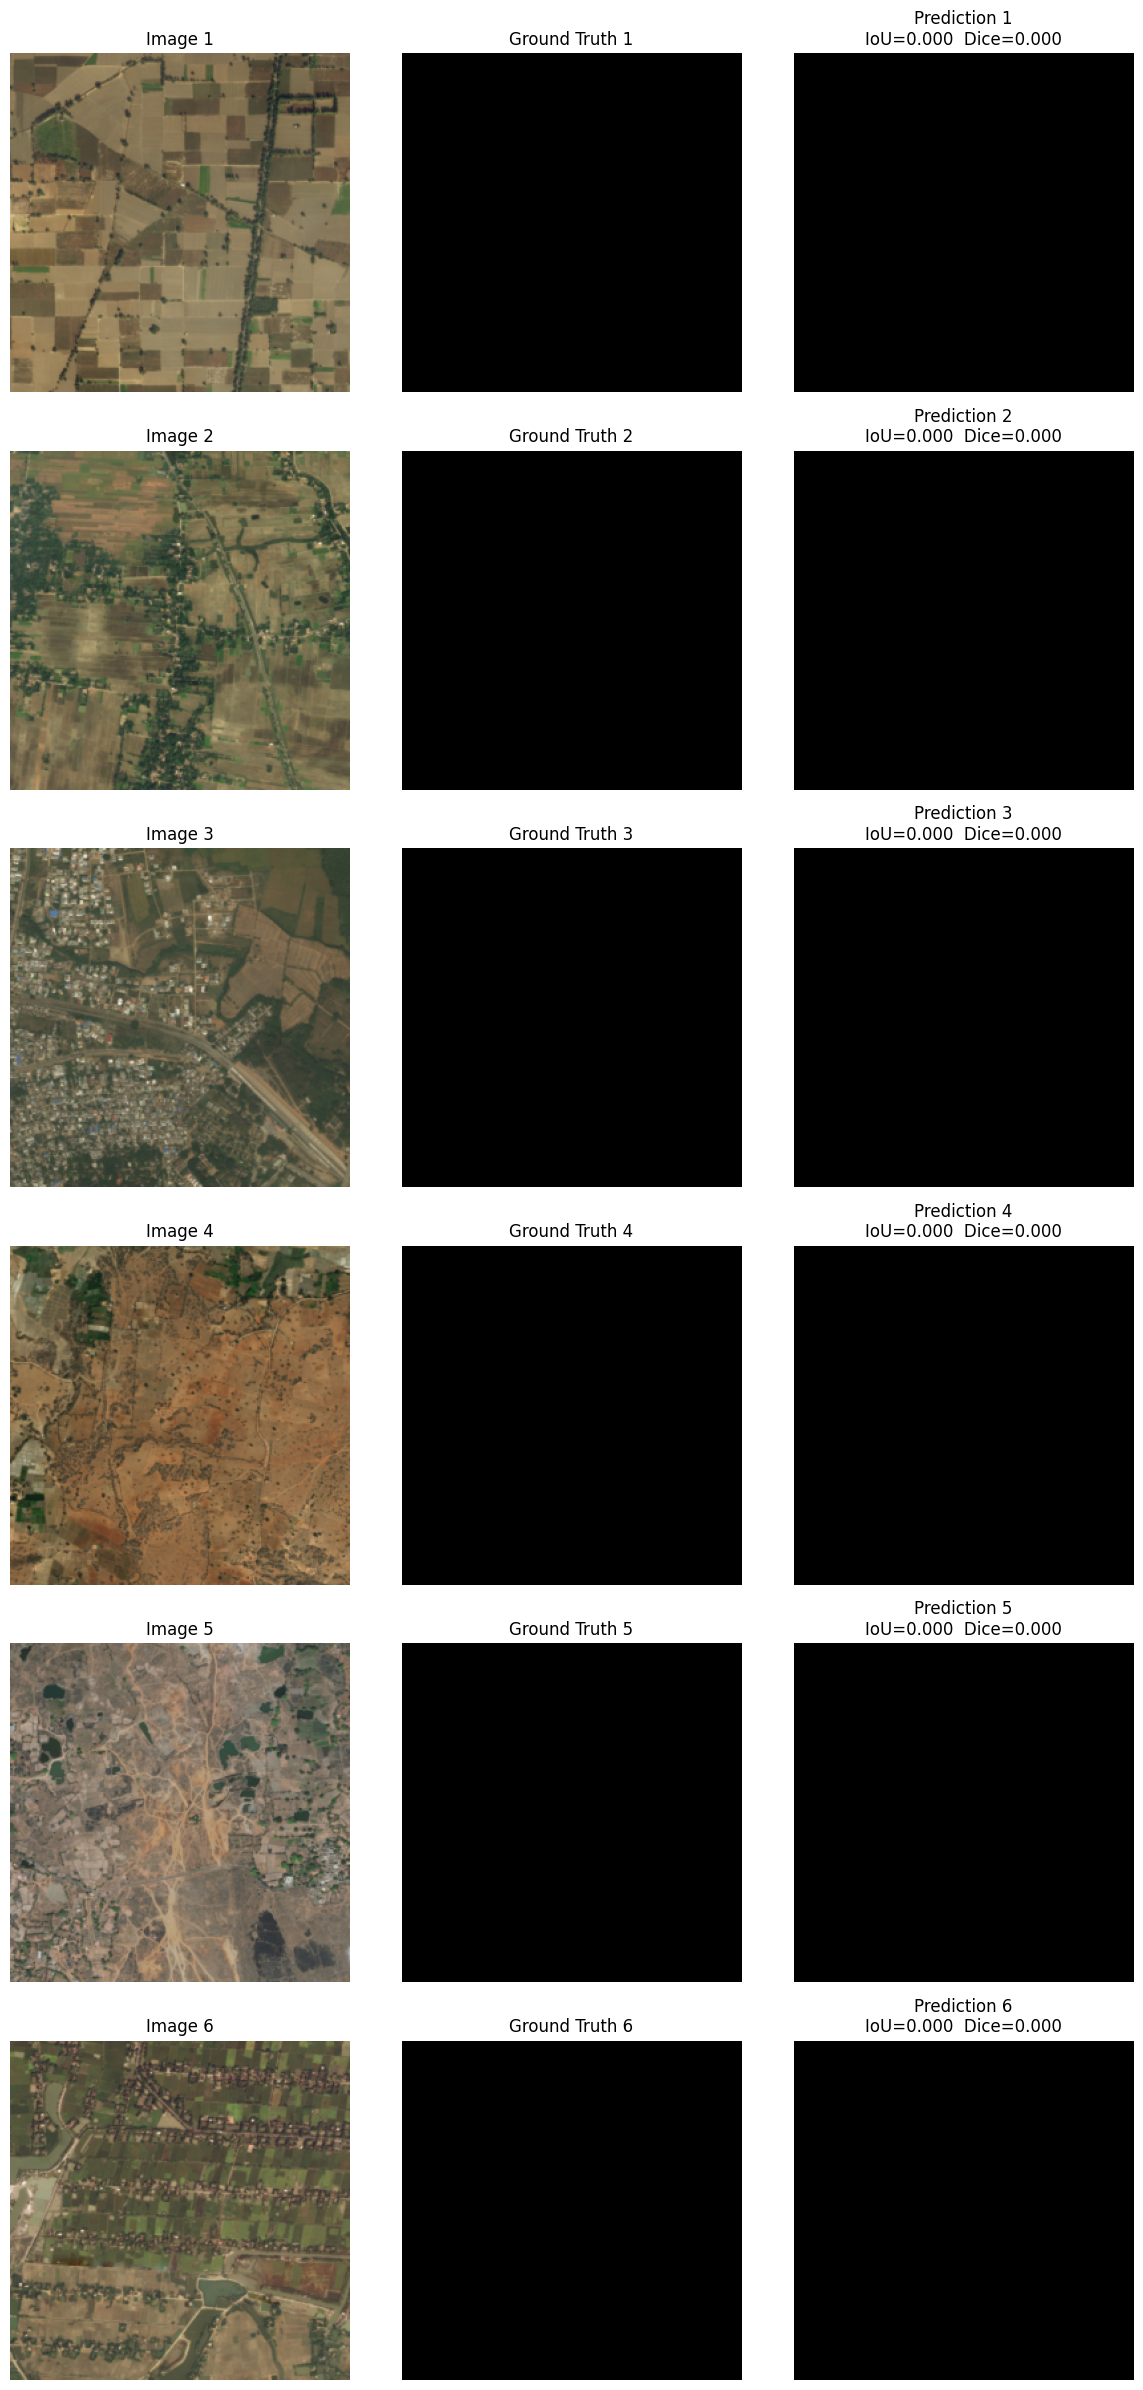

In [ ]:
import matplotlib.pyplot as plt

def denormalize(tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1)

model.eval()

num_samples = 6  # nombre d'images à afficher

fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

for i in range(num_samples):

    image, mask = test_dataset[i]
    image_tensor = image.to(device)

    with torch.no_grad():
        pred = model(image_tensor.unsqueeze(0))
        pred = torch.sigmoid(pred)
        pred = pred.squeeze().cpu()
        pred_bin = (pred > 0.5).float()

    image_display = denormalize(image).permute(1, 2, 0).cpu()

    iou = iou_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()
    dice = dice_score(pred.unsqueeze(0), mask.unsqueeze(0)).item()

    axes[i, 0].imshow(image_display)
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask.squeeze(), cmap="gray")
    axes[i, 1].set_title(f"Ground Truth {i+1}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_bin, cmap="gray")
    axes[i, 2].set_title(f"Prediction {i+1}\nIoU={iou:.3f}  Dice={dice:.3f}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()